In [1]:
# Evoked Potential（EP）诱发电位/诱发反应，是指神经系统在受到特定外界刺激（如闪光、声音、电脉冲）后，
# 脑电或神经电信号中出现的与刺激有锁时关系（time-locked）的电位变化

# 诱发电位振幅往往较低（微伏），通常需要对信号进行平均，以便区分随机产生的噪声

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 读取fif文件创建raw对象
raw_fname = '../data/sample_audvis-ave.fif'

evokeds = mne.read_evokeds(raw_fname, baseline=(None, 0), proj=True)

Reading D:\workspace\practice_mne_demo\notebooks\..\data\sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Right Auditory)
        0 CTF compensation matrices available
        nave = 61 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline corr

In [4]:
print(evokeds)

[<Evoked | 'Left Auditory' (average, N=55), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MiB>, <Evoked | 'Right Auditory' (average, N=61), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MiB>, <Evoked | 'Left visual' (average, N=67), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MiB>, <Evoked | 'Right visual' (average, N=58), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MiB>]


In [5]:
# condition='Left Auditory' 指定读取标签为"左侧听觉"条件对应的诱发反应
evoked = mne.read_evokeds(raw_fname, condition='Left Auditory')
evoked.apply_baseline((None, 0)).apply_proj()

# 打印 Evoked 对象的基本信息，包括通道数、时间范围、采样点数、基线窗口等。
print(evoked)

Reading D:\workspace\practice_mne_demo\notebooks\..\data\sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
No baseline correction applied
Applying baseline correction (mode: mean)
Projections have already been applied. Setting proj attribute to True.
<Evoked | 'Left Auditory' (average, N=55), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MiB>


In [6]:
# 打印 Evoked 对象的测量信息（Info），包含通道名称、类型、采样频率、通道位置、滤波器设置、坏通道标记等元数据
print(evoked.info)

<Info | 16 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 maxshield: False
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: on, PCA-v2: on, PCA-v3: on, Average EEG reference: on
 sfreq: 600.6 Hz
>


In [7]:
# 打印时间轴数组，表示每个采样点相对于刺激 onset 的时间（单位：秒）
# 例如 array([-0.2, -0.199, ..., 0.499]) 表示从 -0.2 秒到 0.5 秒
print(evoked.times)

[-0.19979521 -0.19813025 -0.19646529 -0.19480033 -0.19313537 -0.19147041
 -0.18980545 -0.18814049 -0.18647553 -0.18481057 -0.18314561 -0.18148065
 -0.17981569 -0.17815073 -0.17648577 -0.17482081 -0.17315585 -0.17149089
 -0.16982593 -0.16816097 -0.16649601 -0.16483105 -0.16316609 -0.16150113
 -0.15983617 -0.15817121 -0.15650625 -0.15484129 -0.15317633 -0.15151137
 -0.14984641 -0.14818145 -0.14651649 -0.14485153 -0.14318657 -0.14152161
 -0.13985665 -0.13819169 -0.13652673 -0.13486177 -0.13319681 -0.13153185
 -0.12986689 -0.12820193 -0.12653697 -0.12487201 -0.12320705 -0.12154209
 -0.11987713 -0.11821217 -0.11654721 -0.11488225 -0.11321729 -0.11155233
 -0.10988737 -0.10822241 -0.10655745 -0.10489249 -0.10322753 -0.10156257
 -0.09989761 -0.09823265 -0.09656769 -0.09490273 -0.09323777 -0.09157281
 -0.08990785 -0.08824289 -0.08657793 -0.08491297 -0.08324801 -0.08158305
 -0.07991809 -0.07825313 -0.07658817 -0.0749232  -0.07325824 -0.07159328
 -0.06992832 -0.06826336 -0.0665984  -0.06493344 -0

In [11]:
# 打印参与平均的 epoch（trial）数量（number of averaged epochs）
# 该值表示这个诱发反应是由多少个有效 trial 叠加平均得到的，
# 数量越多，信噪比通常越高，波形越平滑
print(evoked.nave)

# 打印第一个采样点在原始时间序列中的索引位置
print(evoked.first)

# 打印最后一个采样点在原始时间序列中的索引位置
print(evoked.last)

# 打印该 Evoked 对象的注释/标签，通常描述对应的实验条件
# 例如 'Left Auditory' 表示这是左侧听觉刺激条件下的平均 ERP
print(evoked.comment)

# 打印 Evoked 数据的类型。通常为 'average'（平均值）或 'standard_error'（标准误）
print(evoked.kind)

55
-120
300
Left Auditory
average


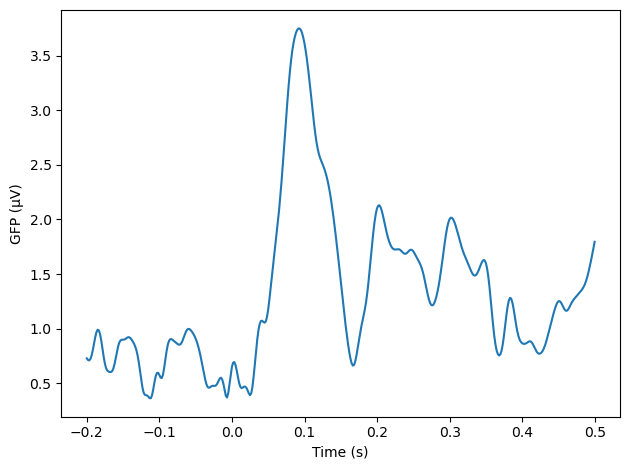

In [15]:
# 计算全局场功率（Global Field Power, GFP）。
# GFP 定义为所有 EEG 通道在同一时间点上电位值的标准差，
# 反映该时刻整个头皮电场分布的"强度"或"空间离散程度"。
# GFP 越高，说明各通道之间的电位差异越大，电场地形越复杂；
# GFP 越低，说明各通道电位趋于一致，地形越平坦。
# 这里先复制 Evoked 对象，然后只保留 EEG 通道（排除 MEG），
# 再沿通道轴（axis=0）计算每个时间点的标准差。
# gfp = evoked.copy.pick_types(eeg=True, meg=False).data.std(axis=0)
gfp = evoked.copy().pick("eeg").data.std(axis=0)

# 创建包含一个子图的 matplotlib 图形
fig, ax = plt.subplots(1)

# 绘制 GFP 随时间变化的曲线。
# gfp/1e-6 将单位从伏特（V）转换为微伏（μV），使纵轴数值更直观
ax.plot(evoked.times, gfp / 1e-6)

# 设置横轴为时间（秒），纵轴为 GFP（微伏）
ax.set(xlabel='Time (s)', ylabel='GFP (μV)')

# 自动调整子图布局，防止标签被截断
fig.tight_layout()

In [16]:
# 读取evoked文件，创建evoked对象
fname = '../data/sample_audvis-ave.fif'
condition='Left Auditory'
evoked = mne.read_evokeds(fname, condition=condition, baseline=(None, 0), proj=True)

Reading D:\workspace\practice_mne_demo\notebooks\..\data\sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)


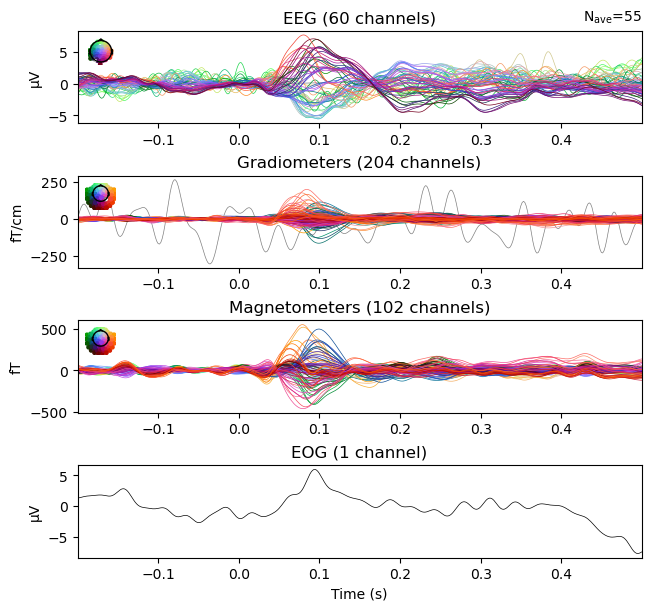

In [17]:
# 绘制 Evoked（ERP/ERF）波形图。
# exclude=[]       : 不排除任何通道，强制显示所有通道的波形（包括被标记为 bad 的通道）。
#                    默认情况下 exclude='bads' 会自动隐藏坏通道，这里设为空列表以查看全部。
# time_unit='s'   : 横轴时间单位使用秒（second），而非毫秒（ms）。
evoked.plot(exclude=[], time_unit='s')

plt.show()

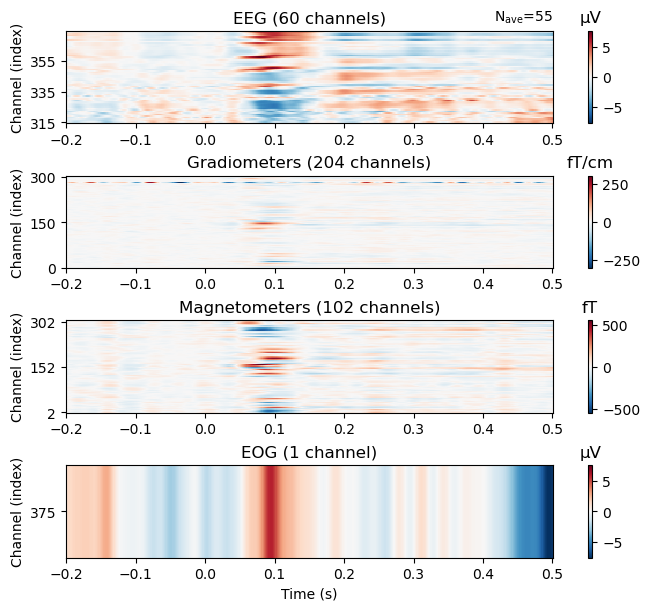

In [18]:
# 以热力图（image/heatmap）形式绘制 Evoked 数据。
# 横轴为时间，纵轴为各通道，颜色深浅表示该时刻该通道的电位/磁场幅值。
# 这种方式可以直观观察 ERP/ERF 成分在时间和空间上的整体分布模式，
# 例如哪些通道在哪些时间段出现了明显的正/负激活。
evoked.plot_image(exclude=[], time_unit='s')

plt.show()

In [ ]:
# 从零创建Evoked对象

<Evoked | 'Smiley faces' (average, N=10), -0.1 – 1.89 s, baseline off, 5 ch, ~18 KiB>
Need more than one channel to make topography for grad. Disabling interactivity.


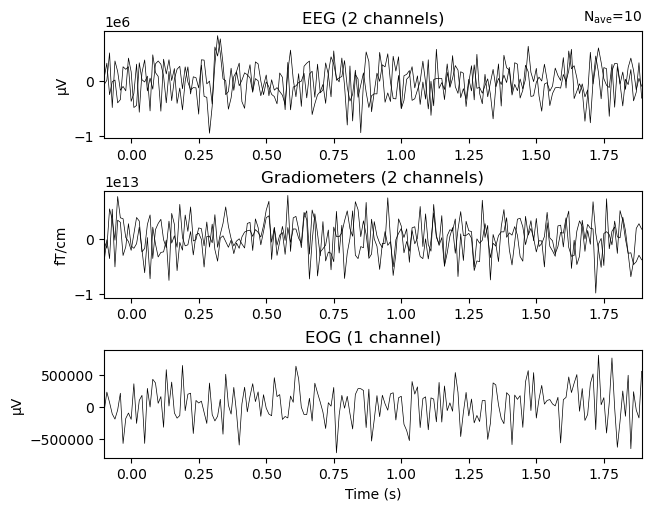

In [19]:
# 采样频率：100 Hz，即每秒采集 100 个采样点
sfreq = 100

# 生成模拟的 epoch 数据，形状为 (n_epochs, n_channels, n_times) = (10, 5, 200)
# 10 个 trial，5 个通道，每个 trial 时长 2 秒（100 Hz × 2 s = 200 个采样点）
# 数据服从标准正态分布，模拟真实的脑电/脑磁信号
data = np.random.randn(10, 5, sfreq * 2)

# 创建 Info 对象，描述通道元信息
# ch_names : 5 个通道的名称
# ch_types : 通道类型，grad=MEG 梯度计，eeg=脑电电极，eog=眼电
# sfreq    : 采样频率 100 Hz
info = mne.create_info(
    ch_names=['MEG1', 'MEG2', 'EEG1', 'EEG2', 'EOG'],
    ch_types=['grad', 'grad', 'eeg', 'eeg', 'eog'],
    sfreq=sfreq,
)

# 沿第 0 轴（epoch 维度）求平均，将 (10, 5, 200) 压缩为 (5, 200)
# 得到每个通道在刺激后平均的时间-幅值波形，即诱发反应（Evoked）
data_evoked = data.mean(0)

# 记录参与平均的 trial 数量（number of averaged epochs），用于后续信噪比评估
nave = data.shape[0]

# 为该 Evoked 对象添加注释/标签，描述对应的实验条件
comment = 'Smiley faces'

# 定义时间轴的起始点（单位：秒），-0.1 表示刺激前 0.1 秒开始
# 结合 sfreq=100 和 n_times=200，时间范围为 -0.1 s 到 1.9 s
tmin = -0.1

# 用平均后的数据和 Info 对象构造 MNE EvokedArray 对象
# data_evoked : 形状为 (n_channels, n_times) 的平均波形数据
# info        : 通道元信息
# tmin        : 时间轴起始点（秒）
# comment     : 实验条件标签
# nave        : 参与平均的 epoch 数量
evoked_array = mne.EvokedArray(data_evoked, info=info, tmin=tmin, comment=comment, nave=nave)

# 打印 Evoked 对象的基本信息
print(evoked_array)

# 绘制各通道的平均 ERP/ERF 波形图
# time_unit='s' : 横轴时间单位使用秒
# 返回值用 _ 接收，避免在 Jupyter 中输出多余的对象信息
_ = evoked_array.plot(time_unit='s')

In [20]:
#

In [21]:
import mne
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

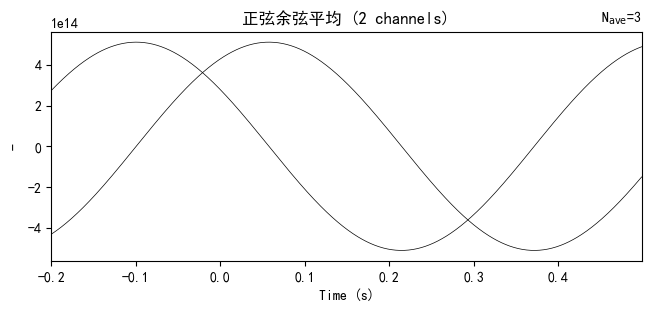

In [24]:
# 定义事件类型编码，所有 trial 都属于同一类事件（编码为 1）
event_id = 1

# 手动构造事件标记数组，形状为 (n_events, 3)
# 每行含义：[采样点索引, 0（占位）, 事件类型编码]
# 三个事件分别发生在第 200、1200、2000 个采样点
events = np.array([[200, 0, event_id],
                   [1200, 0, event_id],
                   [2000, 0, event_id],])

# 采样频率：1000 Hz，即每毫秒一个采样点
sfreq = 1000

# 生成 10 秒的时间轴，步长 0.001 秒（对应 1000 Hz）
times = np.arange(0, 10, 0.001)

# 生成频率为 10 Hz 的正弦波和余弦波，作为模拟的 MEG 信号
sin = np.sin(times * 10)
cos = np.cos(times * 10)

# 手动构造 epoch 数据，形状为 (n_epochs, n_channels, n_times) = (3, 2, 700)
# 3 个 trial，每个 trial 包含 2 个通道，时长 700 个采样点（0.7 秒）
# 数据从正弦/余弦序列中按事件位置截取，模拟刺激后的信号片段
epochs_data = np.array([[sin[:700], cos[:700]],
                        [sin[1000:1700], cos[1000:1700]],
                        [sin[1800:2500], cos[1800:2500]]])

# 定义通道名称和类型
ch_names = ['sin', 'cos']
ch_types = ['mag', 'mag']

# 创建 Info 对象，描述通道元信息
info = mne.create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)

# 记录参与平均的 trial 数量（number of averaged epochs）
nave = len(epochs_data)

# 沿第 0 轴（epoch 维度）求平均，将 (3, 2, 700) 压缩为 (2, 700)
# 得到每个通道在刺激后平均的时间-幅值波形，即诱发反应（Evoked）
evoked_data = np.mean(epochs_data, axis=0)

# 用平均后的数据和 Info 对象构造 MNE EvokedArray 对象
# evoked_data : 形状为 (n_channels, n_times) 的平均波形数据
# info        : 通道元信息
# tmin=-0.2   : 时间轴起始点为刺激前 0.2 秒
# comment     : 实验条件标签
# nave        : 参与平均的 epoch 数量
evokeds = mne.EvokedArray(evoked_data, info=info, tmin=-0.2, comment='Arbitrary', nave=nave)

# 从 Info 对象中挑选 MEG 通道（mag 类型），排除 EEG 和杂项通道
picks = mne.pick_types(info, meg=True, eeg=False, misc=False)

# 绘制平均后的 ERP/ERF 波形图
# picks=picks        : 只显示上面挑选的 MEG 通道
# time_unit='s'     : 横轴时间单位使用秒
# show=True         : 渲染并显示图形窗口
# units={'mag': '-'} : 自定义 MEG 通道的幅值单位显示为 '-'（无单位，因为是模拟数据）
# title={'mag': '正弦余弦平均'} : 为 MEG 通道的波形图设置标题
evokeds.plot(picks=picks, time_unit='s', show=True, units={'mag': '-'}, title={'mag': '正弦余弦平均'})

plt.show()